# Vector data

Companion notebook to deck **02 — A Practical Guide to Spatial Data**
(section *Vector Data*). It reproduces the deck's worked examples and numbers
with GeoPandas, Shapely, and pyproj: read data, inspect and reproject the CRS,
choose a file format, validate geometries, dissolve, and run the everyday
**clip → spatial-join** recipe.

Each example follows the same rhythm: a short lead, the code, the real output,
and one line of interpretation.

In [1]:
# Imports and environment check
import warnings
warnings.filterwarnings("ignore")  # keep the lesson output clean

import geopandas as gpd
import pandas as pd
import shapely
import pyproj
import matplotlib.pyplot as plt

print("geopandas", gpd.__version__)
print("shapely  ", shapely.__version__)
print("pyproj   ", pyproj.__version__)

geopandas 1.1.2
shapely   2.1.2
pyproj    3.7.2


## Read vector data and inspect the CRS

GeoPandas is the Python interface used in this course to work with vector data.
A `GeoDataFrame` is a `pandas.DataFrame` with one active **geometry** column plus
**CRS** metadata, so filtering, grouping, and joins work alongside spatial
methods. Always check `gdf.crs` on load — before any spatial operation.

In [2]:
gdf = gpd.read_file(
    "data/berlin-neighbourhoods/berlin-neighbourhoods.geojson")
print("CRS:   ", gdf.crs)
print("rows:  ", len(gdf))
print("bounds:", gdf.total_bounds)
gdf.head()

CRS:    EPSG:4326
rows:   138
bounds: [13.088354 52.338239 13.761131 52.675509]


,neighbourh,neighbou_1,median_pri,geometry
0,Blankenfelde/Niederschönhausen,Pankow,37.5,"MULTIPOLYGON (((13.41191 52.61487, 13.41183 52..."
1,Helmholtzplatz,Pankow,58.0,"MULTIPOLYGON (((13.41405 52.54929, 13.41422 52..."
2,Wiesbadener Straße,Charlottenburg-Wilm.,50.0,"MULTIPOLYGON (((13.30748 52.46788, 13.30743 52..."
3,Schmöckwitz/Karolinenhof/Rauchfangswerder,Treptow - Köpenick,99.0,"MULTIPOLYGON (((13.70973 52.3963, 13.70926 52...."
4,Müggelheim,Treptow - Köpenick,25.0,"MULTIPOLYGON (((13.73762 52.4085, 13.73773 52...."


The 138 Berlin neighbourhoods load in `EPSG:4326` (lon/lat degrees). The bounds
sit around 13.1–13.8 E, 52.3–52.7 N — Berlin — so the CRS is plausible. Degrees
are fine for storage and display, but *not* for measuring area or distance.

## CRS and area

This is the deck's *GeoPandas example: CRS and area*. We check the CRS, reproject
to a **metric** CRS, then compute area. The CRS choice is part of the measurement
method, not a cosmetic setting.

In [3]:
gdf = gpd.read_file(
    "data/berlin-neighbourhoods/berlin-neighbourhoods.geojson")
print(f"Original CRS: {gdf.crs}")

gdf_utm = gdf.to_crs("EPSG:32633")  # UTM zone 33N (metres)
print(f"New CRS: {gdf_utm.crs}")

gdf_utm["area_sqkm"] = gdf_utm.geometry.area / 1_000_000
print(gdf_utm[["neighbourh", "area_sqkm"]].head())

Original CRS: EPSG:4326
New CRS: EPSG:32633
                                  neighbourh  area_sqkm
0             Blankenfelde/Niederschönhausen  19.660279
1                             Helmholtzplatz   0.713997
2                         Wiesbadener Straße   1.376705
3  Schmöckwitz/Karolinenhof/Rauchfangswerder  17.119849
4                                 Müggelheim  22.186001


With coordinates now in metres (`EPSG:32633`), `.area / 1e6` gives km². The same
`.area` call on the original degrees would return a meaningless number.

> **Lesson —** reproject to a *metric* CRS before measuring area or distance —
> computing `.area` on degrees returns meaningless numbers.

## Low-level reprojection with `pyproj`

When the input is a raw coordinate array rather than a spatial table, use
`pyproj` directly — it is the same PROJ machinery GeoPandas calls in `to_crs`.
Build a `Transformer` once and reuse it. `always_xy=True` fixes `(lon, lat)` →
`(x, y)` order and avoids axis-order ambiguity.

In [4]:
from pyproj import CRS, Transformer

# From WGS 84 (lon/lat) to Web Mercator (metres)
transformer = Transformer.from_crs(
    CRS("EPSG:4326"), CRS("EPSG:3857"), always_xy=True)

lon, lat = -117.16, 32.71  # San Diego
x, y = transformer.transform(lon, lat)
print(f"Original (lon, lat): ({lon}, {lat})")
print(f"Projected (x, y): ({x:.2f}, {y:.2f})")

Original (lon, lat): (-117.16, 32.71)
Projected (x, y): (-13042191.54, 3856874.27)


San Diego's `(-117.16, 32.71)` degrees become `(-13042191.54, 3856874.27)` metres
in Web Mercator. Note that `EPSG:3857` is a *display* CRS — do not measure on it.

> **Lesson —** `pyproj.Transformer` reprojects raw coordinate arrays; set
> `always_xy=True` so `(lon, lat)` input is never silently swapped.

## Vector formats: GeoPackage (`.gpkg`)

A GeoPackage is a single SQLite file that can hold many layers plus their spatial
indexes, storing CRS and attributes without loss. Treat it as your default
working format: write once, read any layer back by name. Here we switch to the
**Texas counties** layer used by the rest of this notebook.

In [5]:
import os
os.makedirs("outputs", exist_ok=True)

# Write to a new GeoPackage layer
gdf = gpd.read_file("data/texas/texas.geojson")
gdf.to_file("outputs/data.gpkg", layer="texas", driver="GPKG")

# Read a specific layer back
gpkg = gpd.read_file("outputs/data.gpkg", layer="texas")
print(len(gpkg), gpkg.crs)

254 EPSG:4326


The round-trip returns all **254** counties and preserves `EPSG:4326`: no rows
lost, no CRS dropped.

> **Lesson —** prefer GeoPackage as the system of record — one file, many layers,
> lossless CRS and attributes, spatial index included.

## Vector formats: Shapefile (`.shp`)

The Shapefile is a 1990s format that travels as a bundle of sidecar files
(`.shp/.shx/.dbf/.prj`) and silently truncates field names to 10 characters.
Treat it as an interchange format you read from, not the system of record you
write to.

In [6]:
cols = ["NAME", "STATE_NAME", "HR90", "geometry"]
gdf[cols].to_file("outputs/texas.shp")  # writes .shp/.shx/.dbf/.prj

shp = gpd.read_file("outputs/texas.shp")
print(list(shp.columns))

['NAME', 'STATE_NAME', 'HR90', 'geometry']


These short names survive intact. Any attribute longer than 10 characters would
be cut (e.g. `population_density` → `population`), and name collisions then get a
numeric suffix — a classic Shapefile foot-gun.

> **Lesson —** read from Shapefiles, but don't make them your system of record —
> the 10-character field-name limit silently mangles attributes.

## Validate and fix geometries

Self-intersections and slivers make predicates and overlays misbehave, so screen
for them on load. Prefer `make_valid()` — it repairs geometry topologically —
over the old `buffer(0)` trick, which can quietly drop or distort parts.

In [7]:
berlin = gpd.read_file(
    "data/berlin-neighbourhoods/berlin-neighbourhoods.geojson")
invalid = ~berlin.is_valid
berlin.loc[invalid, "geometry"] = berlin.loc[invalid, "geometry"].make_valid()
print(f"Fixed {int(invalid.sum())} invalid geometries")

Fixed 0 invalid geometries


This Berlin layer is already clean — **0** invalid geometries — but the check
costs nothing and catches the layers that are not.

> **Lesson —** screen `is_valid` on load and repair with `make_valid()`; never
> assume a downloaded layer is topologically clean.

## Spatial index and performance

Spatial joins are quadratic if you test every feature against every other one. A
spatial index (`gdf.sindex`, a GEOS-backed STRtree) turns that into a fast
bounding-box lookup. Here we query the index for counties whose bounding box
intersects a small window around Austin.

In [8]:
counties = gpd.read_file("data/texas/texas.geojson")
# A small query window around Austin (lon/lat)
from shapely.geometry import box
window = box(-98.0, 30.0, -97.5, 30.5)

hits = list(counties.sindex.query(window))
print(f"{len(hits)} of {len(counties)} counties share the query window's bbox")
print(sorted(counties.iloc[hits]["NAME"].tolist())[:6])

6 of 254 counties share the query window's bbox
['Bastrop', 'Burnet', 'Caldwell', 'Hays', 'Travis', 'Williamson']


The STRtree returns a handful of candidate counties instead of scanning all 254 —
the bounding-box prefilter that keeps large spatial joins tractable.

> **Lesson —** prefilter with `.sindex` (a bounding-box lookup) before any
> expensive per-geometry predicate, or the join scales as O(N×M).

## Aggregate and dissolve

`dissolve` is `groupby` for geometry: it merges all features sharing a key into
one shape while aggregating their attributes. Here we melt 254 Texas counties up
into the single state outline — and only measure area *after* reprojecting to an
equal-area CRS, never in degrees.

In [9]:
gdf = gpd.read_file("data/texas/texas.geojson")  # 254 counties
out = gdf.to_crs("EPSG:6933")  # world cylindrical equal-area (m)

by_state = out.dissolve(by="STATE_NAME", aggfunc="sum")  # counties -> state
by_state["area_km2"] = by_state.geometry.area / 1_000_000
print(by_state[["area_km2"]].round(0))

            area_km2
STATE_NAME          
Texas       684886.0


The 254 county polygons merge into one Texas polygon of ~**684,886 km²**,
measured in an equal-area CRS (`EPSG:6933`).

> **Lesson —** `dissolve` is `groupby` for geometry; take areal measurements only
> in an equal-area CRS, after the merge.

## Vector Recipe: reading, clipping, and joining

The everyday vector pattern is *read polygons, build points, keep the points that
fall inside, then label each point with the polygon it lands in*. We read Texas
counties, turn an Airbnb listings CSV into a point layer, **clip** away stray
geocodes outside the state, then **spatial-join** every listing to its county.

In [10]:
# 1. Read bundled polygons: Texas counties (EPSG:4326)
cols = ["NAME", "STATE_NAME", "geometry"]
counties = gpd.read_file("data/texas/texas.geojson")[cols]

# 2. Build a point layer from a CSV of Airbnb listings (lon/lat columns)
df = pd.read_csv("data/texas/listings.csv.gz")
pts = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326",
)

# 3. CLIP: keep only the points that fall inside the Texas counties
inside = gpd.clip(pts, counties)
print(len(pts), "->", len(inside))  # one stray geocode dropped

5835 -> 5834


`clip` drops the listings that fall outside the county polygons: **5835 → 5834**,
one stray geocode removed. Now every remaining point is guaranteed to sit inside
Texas.

In [11]:
# 4. JOIN: attach to each listing the county it sits in
listings_by_county = gpd.sjoin(
    inside, counties, how="inner", predicate="within")
print(listings_by_county["NAME"].value_counts().head(3))

NAME
Travis        5792
Williamson      35
Hays             7
Name: count, dtype: int64


`sjoin(predicate="within")` tags each point with its containing county. The count
is dominated by **Travis (Austin) = 5792**, then Williamson 35 and Hays 7 — the
Austin metro, exactly as the deck reports.

> **Lesson —** clip, then `sjoin(predicate="within")`: the vector workhorse that
> tags each point with the polygon containing it in one pass.

## Map the result

A choropleth of listings per county turns the join into a picture: the counts
concentrate almost entirely in Travis, so we plot on a log-friendly scale and
outline the state for context.

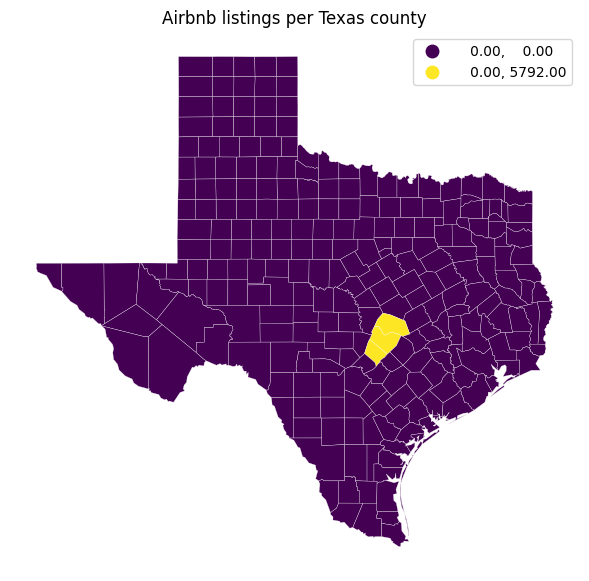

In [12]:
counts = (listings_by_county["NAME"].value_counts()
          .rename("listings").reset_index()
          .rename(columns={"index": "NAME"}))
tx = counties.merge(counts, on="NAME", how="left")
tx["listings"] = tx["listings"].fillna(0)

ax = tx.plot(column="listings", scheme="quantiles", k=5, cmap="viridis",
             legend=True, edgecolor="white", linewidth=0.2, figsize=(8, 7))
ax.set_title("Airbnb listings per Texas county")
ax.axis("off")
plt.show()

The map confirms the join: one bright county (Travis/Austin) against a near-empty
state — the spatial signature of a single-city listings sample.

> **Lesson —** always map the output of a spatial join; a glance validates the
> counts and exposes mis-geocoded points a table would hide.

## Summary

- **Check the CRS on load**, and reproject to a metric or equal-area CRS *before*
  measuring area or distance.
- **GeoPackage** is the lossless default; read from Shapefiles but don't write
  your system of record to them.
- **Validate geometries** with `make_valid()` and **prefilter** with `.sindex`.
- **`dissolve`** aggregates geometry by key; **clip → `sjoin`** is the everyday
  point-in-polygon workflow (Texas listings → Travis 5792).

Deck **02** covers the concepts; deck **03** moves from in-memory analysis to
persistent, indexed, and scalable spatial data management.